***
*Project:* [Artificial Neuroscience: metrology and engineering for Deep Learning using Linear Algebra](https://www.seresearch.qmul.ac.uk/cmai/people/msandler/#grants)

*Author:* Jingwei Liu, Postdoctoral Research Associate, School of EECS, Queen Mary University of London

[[Centre for Digital Music (C4DM)](https://www.c4dm.eecs.qmul.ac.uk/people/) & [Centre for Fundamentals of AI and Computational Theory](https://www.seresearch.qmul.ac.uk/cfcs/people/jiliu/)]
***

# <span style="background-color:darkorange; color:white; padding:2px 6px">Demo</span> 

# Low Rank Structure on Linear Weights

*Updated:* March 23, 2026

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import librosa
import numpy as np
import torch
from IPython.display import Audio
import matplotlib.pyplot as plt
from utils0_loss import plot_training_curves, plot_training_curves_dual_round
from utils1_weights import extract_2d_weights_from_state_dict, classify_convtasnet_weights
from utils2_svd import compute_svd, compute_effective_rank
from utils4_analysis import factorize_linear_weights
from utils_Conv_Tas_Net import ConvTasNet

## 1. 🎧 Conv-Tas Net for Audio Source Separation

<div align="center">
    <img src="Conv-TasNet.jpg" width="1000">
    <p><b>Figure 1:</b> Conv-TasNet block diagram and system flow for time-domain source separation.</p>
</div>

In [2]:
model = ConvTasNet(
    num_sources=2,
    encoder_dim=512,
    feature_dim=128,
    sample_rate=8000,
    window_ms=2,
    num_layers=8,
    num_stacks=3,
    kernel_size=3,
    causal=False,
    use_skip=True
)

Loading TensorBoard scalars...
Available TensorBoard scalar tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 100 data points (epoch 1 → 100)
  Loaded 'Epoch/Val_Loss': 100 data points (epoch 1 → 100)

Loading best_val_loss from checkpoints...
  Loaded best_val_loss from checkpoints: 100 data points (epoch 1 → 100)


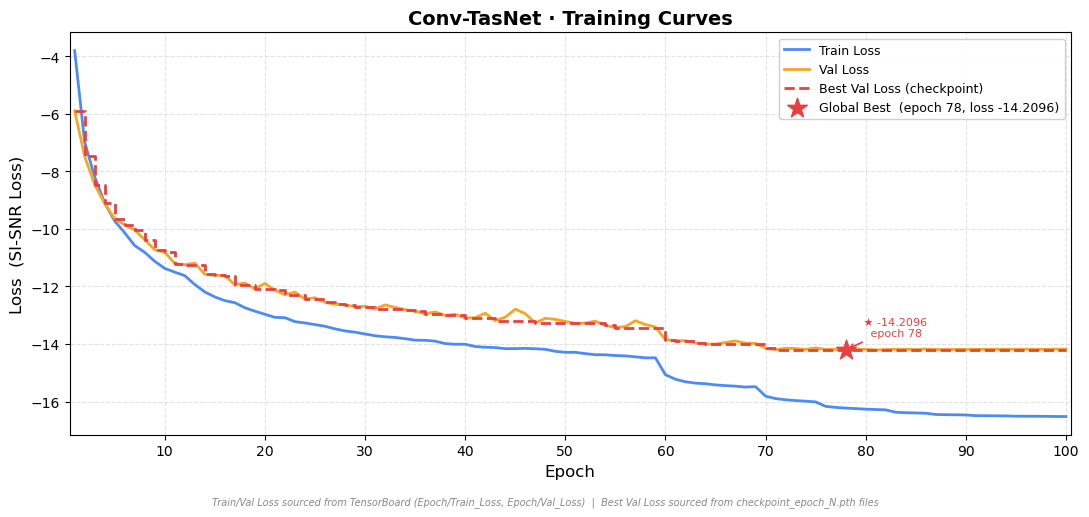

In [3]:
fig = plot_training_curves(
    log_dir        = 'HPC_Trained/Task1/logs',           # your SummaryWriter log_dir
    checkpoint_dir = 'HPC_Trained/Task1/checkpoints',    # your checkpoint_dir
    # save_path      = 'training_curves.png',
    figsize        = (11, 5),
    dpi            = 150,
    smooth_window  = 1,                  # set > 1 (e.g. 5) to smooth noisy curves
)
plt.show()

In [4]:
checkpoint = torch.load('HPC_Trained/Task1/checkpoints/best_model.pth', map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [5]:
mixed_signal, _ = librosa.load('D:\Datasets\Source_Separation_Dataset\Data\LibriSpeech\Libri2Mix\\test-clean\mix_clean\\61_237_1793.wav', sr=8000) # test
Audio(mixed_signal, rate=8000)

In [6]:
model.eval()  # Set model to evaluation mode
with torch.no_grad():
    separated_signal = model(torch.FloatTensor(mixed_signal).unsqueeze(0))
separated_signal.shape

torch.Size([1, 2, 35880])

In [7]:
Audio(separated_signal[:,0,:].squeeze(), rate=8000)

In [8]:
Audio(separated_signal[:,1,:].squeeze(), rate=8000)

## 2. ✂️ Low-Rank Approximation via SVD

Given a weight matrix $W \in \mathbb{R}^{m \times n}$, its singular value decomposition is

$$
W = U \Sigma V^T
$$

where

$$
\Sigma = \operatorname{diag}(\sigma_1, \sigma_2, \dots, \sigma_r), \qquad
\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_r > 0.
$$

To form a rank-$k$ approximation, we keep only the top $k$ singular values and their corresponding singular vectors:

$$
W_k = U_k \Sigma_k V_k^T
$$

where

$$
U_k = [u_1, u_2, \dots, u_k], \qquad
\Sigma_k = \operatorname{diag}(\sigma_1, \dots, \sigma_k), \qquad
V_k = [v_1, v_2, \dots, v_k].
$$

Equivalently,

$$
W_k = \sum_{i=1}^{k} \sigma_i u_i v_i^T.
$$

Thus, $W_k$ preserves only the $k$ most important singular directions of $W$, giving the best rank-$k$ approximation in Frobenius norm:

$$
W_k = \arg\min_{\operatorname{rank}(X)\leq k} \|W - X\|_F.
$$

In [9]:
# Extract all linear weights (pointwise convolution weights) from the Conv-Tas Net
weights_2d = extract_2d_weights_from_state_dict(checkpoint['model_state_dict'])
_, linear_weights = classify_convtasnet_weights(weights_2d)
len(linear_weights)

74

Text(0.98, 0.97, 'Max: 7.31e+00\nMin: 2.39e-02\nCond: 3.06e+02')

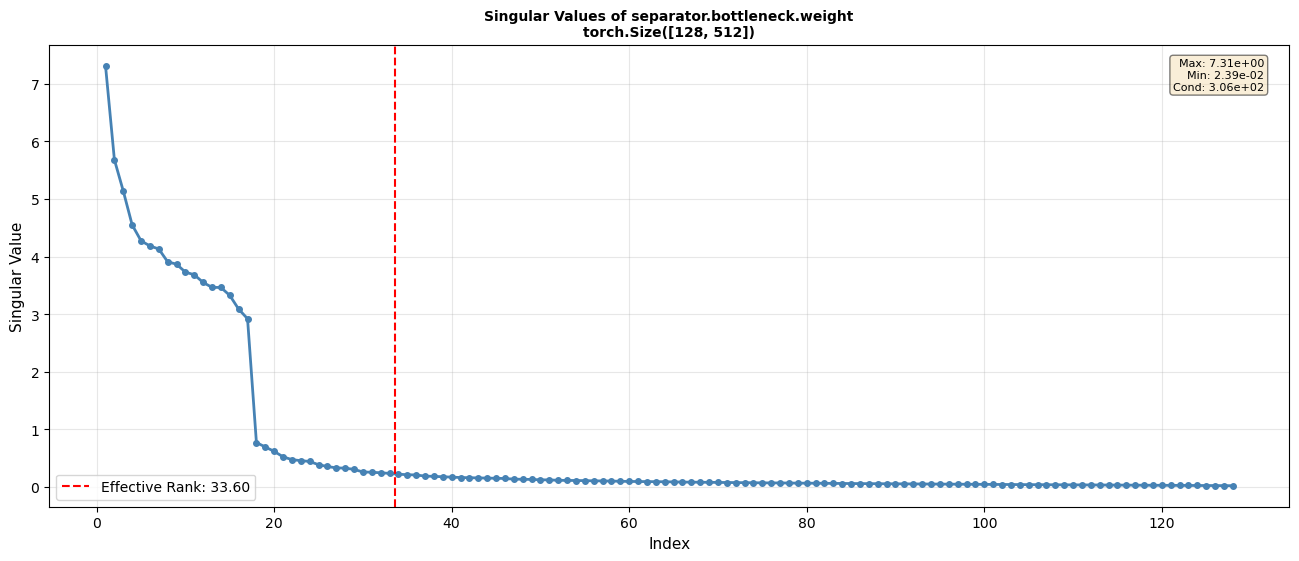

In [10]:
weight = linear_weights[list(linear_weights.keys())[0]]
# Compute SVD
svd_result = compute_svd(weight)
singular_values = svd_result['S'].cpu().numpy()
effective_rank = compute_effective_rank(svd_result['S']).cpu().numpy()

# Plot
fig, ax = plt.subplots(figsize=(16, 6))
indices = np.arange(1, len(singular_values) + 1)
ax.plot(indices, singular_values, 'o-', color='steelblue', linewidth=2, markersize=4)
ax.axvline(effective_rank, color='red', linestyle='--', label=f'Effective Rank: {effective_rank:.2f}')
ax.legend()

# Formatting
ax.set_xlabel('Index', fontsize=11)
ax.set_ylabel('Singular Value', fontsize=11)
ax.set_title(f'Singular Values of {list(linear_weights.keys())[0]}\n{weight.shape}', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add statistics text
max_sv = singular_values[0]
min_sv = singular_values[-1]
condition_number = max_sv / min_sv if min_sv > 0 else float('inf')

textstr = f'Max: {max_sv:.2e}\nMin: {min_sv:.2e}\nCond: {condition_number:.2e}'
ax.text(0.98, 0.97, textstr, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=8)

### 🔧 Balanced Factorization of Weight Matrix as $W=AB$

After computing the truncated SVD of a weight matrix $W \in \mathbb{R}^{m \times n}$ at rank $k$,

$$
W_k = U_k \Sigma_k V_k^T
$$

we re-parameterize the truncated weight as a product of two smaller matrices:

$$
W_k = AB
$$

where

$$
A = U_k \Sigma_k^{1/2} \in \mathbb{R}^{m \times k},
\qquad
B = \Sigma_k^{1/2} V_k^T \in \mathbb{R}^{k \times n}
$$

so that

$$
AB
=
U_k \Sigma_k^{1/2}\Sigma_k^{1/2}V_k^T
=
U_k \Sigma_k V_k^T
=
W_k
$$

This is exactly the low-rank form used to replace a large dense weight matrix by two smaller matrices.

### 📉 Parameter Reduction via Low-Rank Factorization

$$
\underbrace{
\begin{bmatrix}
w_{11} & w_{12} & w_{13} & \cdots & w_{1n} \\
w_{21} & w_{22} & w_{23} & \cdots & w_{2n} \\
w_{31} & w_{32} & w_{33} & \cdots & w_{3n} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
w_{m1} & w_{m2} & w_{m3} & \cdots & w_{mn}
\end{bmatrix}
}_{W \in \mathbb{R}^{m \times n}}
=
\underbrace{
\begin{bmatrix}
a_{11} & \cdots & a_{1k} \\
a_{21} & \cdots & a_{2k} \\
a_{31} & \cdots & a_{3k} \\
\vdots & \ddots & \vdots \\
a_{m1} & \cdots & a_{mk}
\end{bmatrix}
}_{A \in \mathbb{R}^{m \times k}}
\underbrace{
\begin{bmatrix}
b_{11} & b_{12} & b_{13} & \cdots & b_{1n} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
b_{k1} & b_{k2} & b_{k3} & \cdots & b_{kn}
\end{bmatrix}
}_{B \in \mathbb{R}^{k \times n}}
$$

A full matrix $W \in \mathbb{R}^{m \times n}$ has

$$
mn
$$

parameters.

The rank-$k$ factorization $W_k = AB$ uses

$$
mk + kn = k(m+n)
$$

parameters.

So the low-rank approximation reduces parameters whenever

$$
k(m+n) < mn
$$

which is typically true when $k \ll \min(m,n)$.

In [11]:
factored, num_orig_params, num_fact_params = factorize_linear_weights(linear_weights)

separator.bottleneck.weight                              shape ( 128, 512)  k=  34  
separator.conv_layers.0.conv_expand.weight               shape ( 512, 128)  k=  37  
separator.conv_layers.0.conv_residual.weight             shape ( 128, 512)  k= 100  
separator.conv_layers.0.conv_skip.weight                 shape ( 128, 512)  k=  85  
separator.conv_layers.1.conv_expand.weight               shape ( 512, 128)  k=  90  
separator.conv_layers.1.conv_residual.weight             shape ( 128, 512)  k= 111  
separator.conv_layers.1.conv_skip.weight                 shape ( 128, 512)  k= 100  
separator.conv_layers.2.conv_expand.weight               shape ( 512, 128)  k= 100  
separator.conv_layers.2.conv_residual.weight             shape ( 128, 512)  k= 109  
separator.conv_layers.2.conv_skip.weight                 shape ( 128, 512)  k= 103  
separator.conv_layers.3.conv_expand.weight               shape ( 512, 128)  k= 107  
separator.conv_layers.3.conv_residual.weight             shape ( 

In [12]:
num_reduced_params = num_orig_params - num_fact_params
print(num_reduced_params, 'parameters reduced!')

473600 parameters reduced!


## 3. Effects of Truncation on Model Performance

After replacing the original full weight with the truncated weights, we get:

- Original  Model Validation Loss: $-14.21$
- Truncated Model Validation Loss: $-14.00$
- Original  Model Training   Loss: $-16.24$
- Truncated Model Training   Loss: $-15.92$

The model performance only drops slightly, which means the original layer contains **substantial redundancy** and the model can be made much **smaller without sacrificing effectiveness**.

Loading Round 1 — TensorBoard scalars...
Available TensorBoard scalar tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 100 data points (epoch 1 → 100)
  Loaded 'Epoch/Val_Loss': 100 data points (epoch 1 → 100)

Loading Round 1 — checkpoints...
  Loaded best_val_loss from checkpoints: 100 data points (epoch 1 → 100)

Loading Round 2 — TensorBoard scalars...
Available TensorBoard scalar tags: ['Train/Loss', 'Epoch/Train_Loss', 'Epoch/Val_Loss', 'Epoch/Learning_Rate']
  Loaded 'Epoch/Train_Loss': 50 data points (epoch 1 → 50)
  Loaded 'Epoch/Val_Loss': 50 data points (epoch 1 → 50)

Loading Round 2 — checkpoints...
  Loaded best_val_loss from checkpoints: 50 data points (epoch 1 → 50)

Round 1 global best → epoch 78  (loss -14.2096)
Round 2 epoch offset = 78  (R2 local ep 1 → global ep 79)

R2 Train Loss anchor injected at local ep 0 (global ep 78): -15.9204
R2 Val Loss + Best Val Loss anchor injected at local ep 0 (global ep 7

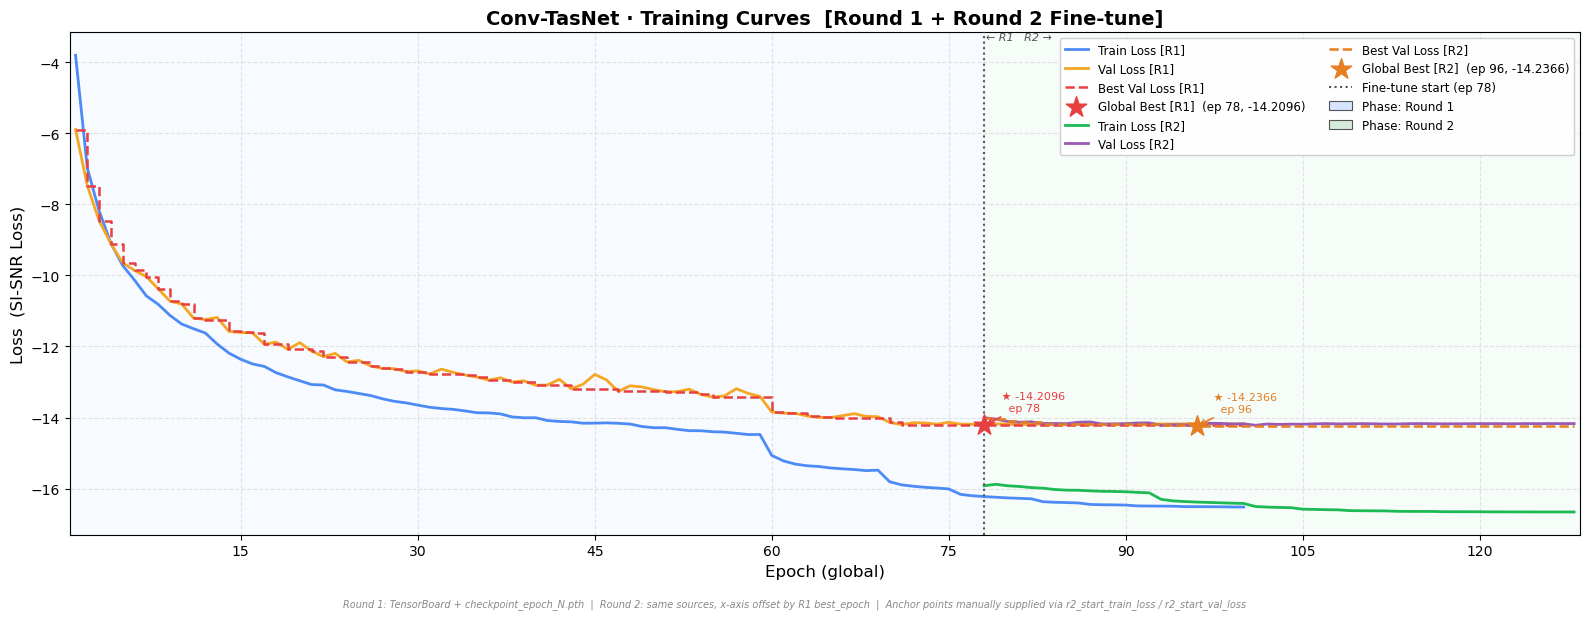

In [20]:
fig = plot_training_curves_dual_round(
    # ── Round 1 paths ──────────────────────────────────
    r1_log_dir        = 'HPC_Trained/Task1/logs',
    r1_checkpoint_dir = 'HPC_Trained/Task1/checkpoints',

    # ── Round 2 paths ──────────────────────────────────
    r2_log_dir        = 'HPC_Trained/Task1_tune_free/logs',
    r2_checkpoint_dir = "HPC_Trained/Task1_tune_free/checkpoints",

    r2_start_train_loss = -15.920419854064964,   
    r2_start_val_loss   = -14.003267823525196,

    # ── Options ────────────────────────────────────────
    # save_path         = "training_dual_round.png",
    figsize           = (16, 6),
    dpi               = 150,
    smooth_window     = 1,     # set to 1 to disable smoothing
)

plt.show()

## 4. Dual-Phase Adaptive Low-Rank (DALR)

The fine-tuning stage gives an even more encouraging result: after only a few epochs, the validation loss improves to $-14.23$, slightly better than the original full model at $-14.20$. This suggests that rank reduction is not merely a way to save parameters or compress model size. Instead, it may reveal a **better structural form** of the weight—one that removes redundancy, keeps the most useful directions, and leads to a more efficient representation for the task. In other words, low-rank structure may act not only as a compression tool, but also as a form of **inductive bias** that can improve optimization and generalization.

This observation naturally leads to a broader question:

> Can we train a compact and efficient model whose rank $k$ is optimized for the task itself?

More specifically, rather than fixing the rank by hand or compressing only after training, we would like to **search for the most effective rank**: one that is small enough to reduce redundancy and model size, yet expressive enough to match—or even outperform—the original full-rank weight matrices. Motivated by this idea, we design several mechanisms for **adaptive low-rank training**, where the model can automatically adjust its rank during learning.

## Training Procedure

- **Every step:**  
  Standard gradient update on $A, B$

- **Every $T$ steps:**
  - **Re-balance $A, B$** — Re-express A, B in the SVD basis and restore the $\Sigma^{1/2}$ split
  - **SVT prune** — zero singular values $\sigma_i < \tau_{\text{prune}}$
  - **Residual probe** — grow rank if $\|\Delta W\|_F > \tau_{\text{grow}}$

- **On convergence:**  
  Freeze rank and export merged weight $W = A B$

---

### 1. Growth Criterion

Growth is determined by the **gradient residual outside the current row and column spaces**:

$$
\Delta W = \underbrace{(I - P_U)}_{\text{left residual}} \; \nabla_W \mathcal{L} \; \underbrace{(I - P_V)}_{\text{right residual}}
$$
​​where $P_U = Q_U Q_U^\top$​ and $P_V = Q_V Q_V^\top$​ are orthogonal projectors onto the column and row spaces of $W$, respectively. If $\|\Delta W\|_F > \tau_{\text{grow}}$, the **top singular direction of $\Delta W$** is appended to the factorization.


### 2. Pruning Criterion

Pruning uses **soft thresholding on the singular values** of the reconstructed matrix $W_k = AB$:

$$
\hat{\sigma}_i \leftarrow \max(\hat{\sigma}_i - \tau_{\text{prune}},\ 0)
$$

Directions where $\hat{\sigma}_i = 0$ are removed, and the corresponding **columns of $A$** and **rows of $B$** are physically deleted.

### 3. Rank Schedule Intuition

- **Early training:** higher rank helps explore the loss landscape.  
- **Late training:** lower rank improves compression and stability.

Therefore the thresholds are **annealed over time**.

### Pruning Threshold (increases over time)

$$
\tau_{\text{prune}}(t)
=
\tau_0
\left(
1 - e^{-t / T_{\text{anneal}}}
\right)
$$

Pruning becomes **more aggressive** as training progresses.

### Growth Threshold (decreases over time)

$$
\tau_{\text{grow}}(t)
=
\tau_0^{\text{grow}}
\cdot
e^{-t / T_{\text{anneal}}}
$$

Rank growth becomes **harder over time**, stabilizing the final model.
